In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
# Dataset
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,n_classes=2,n_redundant=0)

In [47]:
print(X.shape)
print(y.shape)

(1000, 2)
(1000,)


In [48]:
print((pd.DataFrame(X)).head())

          0         1
0  0.716458 -2.530775
1 -1.115170 -0.575931
2  0.785429 -1.446138
3 -0.213399  1.413752
4 -0.843842  0.116414


# Linearly separated dataset

<Axes: xlabel='0', ylabel='1'>

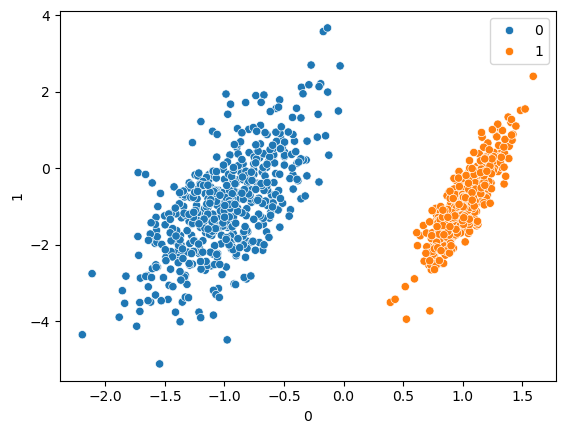

In [49]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1],hue=y)

In [51]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.3,random_state=42)

In [52]:
from sklearn.svm import SVC

svc = SVC(kernel='linear')

In [53]:
svc.fit(X_train,y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [54]:
y_pred = svc.predict(X_test)

In [56]:
print(y_pred)
print(y_test)

[1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0
 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 0 1 0
 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1
 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0
 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 0 1
 0 0 1 1 0 0 0 0 0 1 0 0 1 0 0 1 0 1 1 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 0 0 1
 1 0 1 1 0 0 0 0 0 1 1 1 0 1 0 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 0 0 0 1 1 1 0
 1 1 0 0 1 0 1 0 0 1 0 0 1 0 1 1 0 0 0 1 0 1 1 0 0 1 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0]
[1 1 0 0 0 1 1 0 0 1 0 1 0 1 0 1 1 1 1 0 1 1 0 1 0 0 1 1 0 0 1 1 1 0 1 0 0
 0 1 0 1 0 1 1 0 0 0 0 1 0 1 1 0 1 0 0 1 1 0 0 0 0 1 0 1 1 1 1 0 1 0 0 1 0
 1 1 1 0 0 0 0 1 1 0 0 1 0 1 0 1 1 0 1 0 1 0 1 0 0 0 0 0 1 1 0 1 0 0 0 0 1
 0 0 1 1 1 0 0 0 0 1 1 1 1 1 0 1 1 1 1 0 1 0 1 1 0 0 1 1 1 1 0 0 0 1 1 1 0
 0 1 1 0 1 1 0 0 1 0 1 0 1 1 0 1 1 0 1 1 0 1 0 1 0 1 0 1 1 0 1 1 1 1 1 0 1
 0 0 1 1 0 0 0 

# We got 100% accuracy because it was an a linearly separable data points


In [66]:
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score

print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))
print("\nclassification_report:\n\t", classification_report(y_test,y_pred))
print("\nAccuracy:", accuracy_score(y_test,y_pred)*100)

Confusion matrix:
 [[153   0]
 [  0 147]]

classification_report:
	               precision    recall  f1-score   support

           0       1.00      1.00      1.00       153
           1       1.00      1.00      1.00       147

    accuracy                           1.00       300
   macro avg       1.00      1.00      1.00       300
weighted avg       1.00      1.00      1.00       300


Accuracy: 100.0


# Not Linearly separated dataset

In [77]:
from sklearn.datasets import make_classification
X,y = make_classification(n_samples=1000,n_features=2,n_clusters_per_class=1,n_classes=2,n_redundant=0,random_state=60)

Text(0.5, 1.0, 'Not linearly separable data')

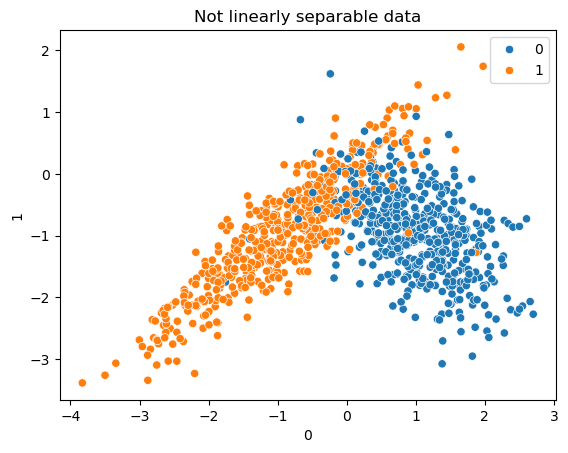

In [79]:
sns.scatterplot(x=pd.DataFrame(X)[0], y=pd.DataFrame(X)[1],hue=y)
plt.title("Not linearly separable data")

# Using RBF kernel 

In [80]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [82]:
rbf = SVC(kernel='rbf')

rbf.fit(X_train,y_train)


,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [83]:
rbf_pred = rbf.predict(X_test)

print(y_test)
print(rbf_pred)

[0 1 0 1 1 0 0 1 1 0 1 0 0 1 0 0 1 1 1 0 1 1 1 0 0 1 1 1 1 0 0 1 0 0 1 0 0
 0 1 1 0 1 0 1 1 1 0 1 0 0 1 1 1 0 1 1 0 0 0 0 0 0 1 0 1 1 0 1 0 0 1 0 1 1
 0 1 0 1 0 1 1 0 0 1 0 0 1 1 1 0 1 0 1 0 0 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1
 1 0 0 1 0 1 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 0 1 1 1 1 0
 0 0 0 0 1 0 0 1 0 0 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 1 0
 0 1 1 0 1 0 1 0 0 0 0 0 0 1 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 1
 0 1 1 0 1 0 1 1 0 0 0 1 0 0 0 0 1 1 0 1 1 1 1 1 1 0 1 0]
[0 1 0 1 1 1 0 1 1 0 1 0 1 1 0 0 1 1 1 0 1 1 0 0 0 1 1 1 0 0 0 1 0 0 1 0 0
 0 1 1 0 1 0 1 1 1 0 1 0 0 1 0 1 0 1 1 0 0 0 1 0 0 1 0 1 1 0 1 0 0 1 0 1 1
 1 1 0 1 0 1 1 0 1 1 0 0 1 1 1 0 1 0 1 0 1 1 1 0 1 1 1 0 1 0 0 0 0 0 0 1 1
 1 0 0 1 0 0 0 0 0 1 0 1 0 0 1 0 1 1 1 1 1 1 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0
 1 0 0 1 1 0 1 1 0 0 1 0 0 0 1 0 1 1 1 0 0 1 0 0 1 1 0 0 1 0 1 1 1 0 1 1 0
 0 1 1 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 1 1 0 1 1 1 0 0 0 0 0 0 1 1 1 1 0 1 1
 1 1 1 0 1 0 1 1 0 0 0 1 0 0 0 1 1 1 0 1 1

# The accuracy has been changed

In [84]:
print("Confusion matrix:\n",confusion_matrix(y_test,rbf_pred))
print("\nclassification_report:\n\t", classification_report(y_test,rbf_pred))
print("\nAccuracy:", accuracy_score(y_test,rbf_pred)*100)

Confusion matrix:
 [[113  12]
 [  6 119]]

classification_report:
	               precision    recall  f1-score   support

           0       0.95      0.90      0.93       125
           1       0.91      0.95      0.93       125

    accuracy                           0.93       250
   macro avg       0.93      0.93      0.93       250
weighted avg       0.93      0.93      0.93       250


Accuracy: 92.80000000000001
